## نجرب الانحدار الخطي 

In [7]:
#نقرا الملف
import pandas as pd 
df = pd.read_csv("sales.csv")
df

,week,total
0,4,88
1,20,62
2,52,118
3,56,149
4,72,193
5,80,167
6,168,192
7,200,229
8,228,319
9,296,311


In [8]:
#الحين نبي نشوف هل الانحدار الخطي يضبط على البيانات ولا غير الخطي 

In [15]:
#اول شيء راح نحدد x , y 
x = df[['week']]
y = df['total']

In [16]:
#المره ذي ما نحتاج  تقسييم البيانات

In [17]:
#راح نسوي نموذج 
from sklearn.linear_model import LinearRegression
model = LinearRegression ()
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# راح نحسب b0 b1
print(round(model.intercept_,2))
print(round(model.coef_[0],2))
# total = 115.99 + 0.53 * week

115.99
0.53


In [23]:
# بعد ما جبنا b0 , b1 خلاص الحين نجرب نتنبئ
# لو تلاحظ ما قسمنا البيانات فراح نتنبئ على البيانات الحقيقه 
pred = model.predict(x)
print(pred)

[118.1201943  126.62116997 143.62312132 145.74836523 154.2493409
 158.49982874 205.25519493 222.25714627 237.13385369 273.26300029
 303.01641514 324.26885431 343.39604957 351.89702524 381.65044009]


In [32]:
# الحين نبي نقيس اداء التنبؤ 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt

# حساب المقاييس باستخدام بيانات الاختبار الفعلية والمتوقعة
mse = mean_squared_error(pred, y)
rmse = sqrt(mse)
mae = mean_absolute_error(pred, y)
print('mse:', round(mse, 2))
print('rmse:', round(rmse, 2))
print('mae:', round(mae, 2))
#لو تلاحظ الخطا كبير  لان الانحدار الخطي النقاط البينات بعيده عنه

mse: 1915.78
rmse: 43.77
mae: 37.41


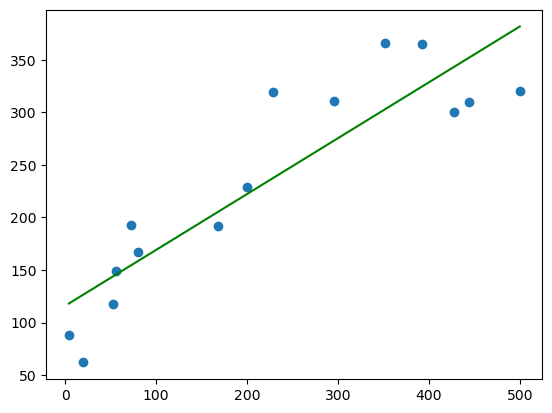

In [40]:
# راح نرسمها بياني غشان توضح لك بعد النقاط عن الخط 
df['predict']= model.predict(x)
import matplotlib.pyplot as plt

xpoint = df['week']
ypoint = df['total']
yprediction = df['predict']

plt.scatter(xpoint , ypoint)
plt.plot(xpoint , yprediction , color = 'green')
plt.show()

## الان نجرب الانحدار الغير خطي 

In [44]:
# polynomialfeatures هو يخلينا نضيف عمود جديد و نحدد اي درجه نبيها 
#يعني باختصار الغير خطي لازم تحط على عمود اكس تربيع ثم تسوي الانحدار الخطي على البيانات
from sklearn.preprocessing import PolynomialFeatures

polynomial = PolynomialFeatures (degree = 2 , include_bias= False )

xnew = polynomial.fit_transform(x)

xnew
#هنا سويتا عمود اكس و جمبه عمود تربيع الاكس 

array([[4.00000e+00, 1.60000e+01],
       [2.00000e+01, 4.00000e+02],
       [5.20000e+01, 2.70400e+03],
       [5.60000e+01, 3.13600e+03],
       [7.20000e+01, 5.18400e+03],
       [8.00000e+01, 6.40000e+03],
       [1.68000e+02, 2.82240e+04],
       [2.00000e+02, 4.00000e+04],
       [2.28000e+02, 5.19840e+04],
       [2.96000e+02, 8.76160e+04],
       [3.52000e+02, 1.23904e+05],
       [3.92000e+02, 1.53664e+05],
       [4.28000e+02, 1.83184e+05],
       [4.44000e+02, 1.97136e+05],
       [5.00000e+02, 2.50000e+05]])

In [46]:
#هنا نرجع نسوي الانحدار الخطي لكن عمود الاكس فيه عمود الاكس العادي و الاكس تربيع
model2 = LinearRegression()

model2 = model2.fit(xnew,y)

In [48]:
# نحسب b0 b1 
print('the b0 : ',  model2.intercept_)
print('the b1 : ',  model2.coef_)
#اي بمعنى صار زي كذا total = 65.98 + 1.33 * week - 0.0016 * week^2

the b0 :  65.98710740550436
the b1 :  [ 1.33308721 -0.00166673]


In [50]:
#الحين نخليه يتنبئ 
pred2  = model2.predict(xnew)
pred2

array([ 71.29278849,  91.98215796, 130.8007934 , 135.41311313,
       153.32903716, 161.96698624, 242.90385695, 265.9351876 ,
       283.28748874, 314.5483517 , 328.71879064, 332.44027404,
       331.22942477, 329.30454682, 315.84720236])

In [57]:
# راح نقيس النموذج الثاني
print('the mse :', round(mean_squared_error(pred2, y),2)) 
print('the rmse :',round(sqrt(mean_squared_error(pred2, y)),2)) 
print('the mae :', round(mean_absolute_error(pred2, y),2))   
#نلاحظ ان في فرق بين نموذج الاول و الثاني 

the mse : 812.28
the rmse : 28.5
the mae : 24.63


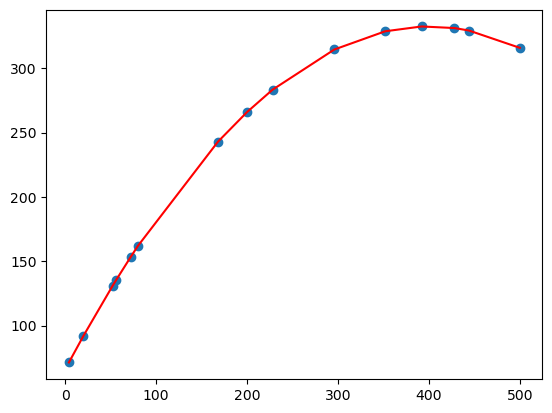

In [64]:
#الحين نبي نرسم النموذج الثاني 
df['predict-non-linear']= model2.predict(xnew)
xpoints = df['week']
ypoints = df['total']
yprediction2= df['predict-non-linear']
plt.scatter(xpoints , yprediction2)
plt.plot(xpoints , yprediction2 , color = 'red')
plt.show()
#نلاحظ ان الانحدار الغير خطي افضل 

In [69]:
# الحين نبي نقوله تنبى بعد 500 اسبوع كم المبيعات 
weeks = [[550]]
weeksnew = polynomial.fit_transform(weeks) # الي هو xnew
yspred = model2.predict(weeksnew)
print(yspred)
# توقعها وهي 294 قطعه

[294.99802584]
